# **Phase 4: GenAI, BERT, and Customer Narratives**




In [1]:
#installing hugging face transformer library
!pip install transformers

In [2]:
from google.colab import drive
import pandas as pd
import joblib
import torch
from transformers import BertTokenizer, BertModel

# Mount Drive
drive.mount('/content/drive')

print("Advanced AI Libraries Loaded.")

Mounted at /content/drive
Advanced AI Libraries Loaded.


In [3]:
# Load the trained Random Forest model
model_path = "/content/drive/MyDrive/Customer Churn Prediction/models/churn_model_rf.pkl"
rf_model = joblib.load(model_path)

# Load the processed data
data_path = "/content/drive/MyDrive/Customer Churn Prediction/data/clean/processed_churn_data.csv"
df = pd.read_csv(data_path)

print("Model and Data re-loaded for Advanced Analysis.")

Model and Data re-loaded for Advanced Analysis.


In [4]:
# Initializing Pretrained BERT from HuggingFace
# 'bert-base-uncased' is the standard model that understands English context
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')

def get_bert_embeddings(text):
    # Encoding the text and passing it through the BERT model
    # torch.no_grad() saves memory as we are not training the model further
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128)
    with torch.no_grad():
        outputs = bert_model(**inputs)

    # Extracting the Mean of the last hidden state to get a single vector for the sentence
    # separating training graph from tensor because no need of training now (batchsize, sequence_length, hidden_size)
    return outputs.last_hidden_state.mean(dim=1).detach().numpy()

print("BERT Engine is Ready! Now we can convert customer profiles into semantic vectors.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT Engine is Ready! Now we can convert customer profiles into semantic vectors.


In [5]:
# Every Narrative-> BERT FUNCTION -> VECTOR GENERATION
# Function to convert tabular data into a descriptive narrative
def create_customer_narrative(row):
    tenure_status = "Long-term client" if row['tenure'] > 24 else "New client"
    charges_status = "High-paying" if row['MonthlyCharges'] > 70 else "Low-paying"

    # We use .get() to avoid errors if some columns are missing in the sample
    contract = "Month-to-Month"
    if row.get('Contract_One year', 0) == 1: contract = "One-Year"
    if row.get('Contract_Two year', 0) == 1: contract = "Two-Year"

    return f"This {tenure_status} is a {charges_status} customer on a {contract} contract."

# Use full dataset
sample_df = df.copy()

# Generate narratives
sample_df['Customer_Narrative'] = sample_df.apply(create_customer_narrative, axis=1)

# Generate BERT embeddings
print("Generating Semantic Embeddings...")
sample_df['BERT_Vector'] = sample_df['Customer_Narrative'].apply(get_bert_embeddings)

# Preview only first 5
print("\n--- BERT Analysis Preview ---")
for i, row in sample_df.head(5).iterrows():
    print(f"Customer {i+1}: {row['Customer_Narrative']}")
    print(f"Vector Preview: {row['BERT_Vector'][0][:3]}...\n")

Generating Semantic Embeddings...

--- BERT Analysis Preview ---
Customer 1: This New client is a Low-paying customer on a Month-to-Month contract.
Vector Preview: [-0.06851263 -0.12825496  0.41568002]...

Customer 2: This Long-term client is a Low-paying customer on a One-Year contract.
Vector Preview: [-0.08632655 -0.19149229  0.47201505]...

Customer 3: This New client is a Low-paying customer on a Month-to-Month contract.
Vector Preview: [-0.06851263 -0.12825496  0.41568002]...

Customer 4: This Long-term client is a Low-paying customer on a One-Year contract.
Vector Preview: [-0.08632655 -0.19149229  0.47201505]...

Customer 5: This New client is a High-paying customer on a Month-to-Month contract.
Vector Preview: [-0.02252834 -0.1269379   0.56660604]...



In [6]:
# Function to analyze sentiment and extract pain points
def analyze_customer_journey(row):
    # Logic for Sentiment and Pain Points based on data (Baseline initialization)
    sentiment = "Neutral"
    pain_points = "None identified"
    risk_factor = "Low"

    # Analyzing specific conditions (Month to Month contract)
    if row['Contract_One year'] == 0 and row['Contract_Two year'] == 0:
        sentiment = "Negative"
        pain_points = "Lack of long-term contract stability"
        risk_factor = "High (Month-to-Month volatility)"

    if row['MonthlyCharges'] > 70:
        sentiment = "Frustrated"
        pain_points += ", High service costs"
        risk_factor = "Very High (Price sensitivity)"

    summary = f"Risk Factor: {risk_factor}. Customer is likely feeling {sentiment.lower()} due to {pain_points}."
    return summary, sentiment, pain_points

# Applying the analysis to our sample
analysis_results = sample_df.apply(analyze_customer_journey, axis=1)
sample_df['AI_Summary'] = [r[0] for r in analysis_results]
sample_df['Sentiment'] = [r[1] for r in analysis_results]
sample_df['Pain_Points'] = [r[2] for r in analysis_results]

#List of tuples [("summary 1,"sentiment 1","pain 1"),("summary 2,"sentiment 2","pain 2"),....]
print("--- Final AI Customer Insights ---")
for i, row in sample_df.iterrows():
    print(f"Customer {i+1} Journey Summary: {row['AI_Summary']}")
    print(f"Extracted Sentiment: {row['Sentiment']}")
    print(f"Primary Pain Point: {row['Pain_Points']}")
    print("-" * 30)

Streaming output truncated to the last 5000 lines.
Customer 5783 Journey Summary: Risk Factor: Very High (Price sensitivity). Customer is likely feeling frustrated due to Lack of long-term contract stability, High service costs.
Extracted Sentiment: Frustrated
Primary Pain Point: Lack of long-term contract stability, High service costs
------------------------------
Customer 5784 Journey Summary: Risk Factor: Very High (Price sensitivity). Customer is likely feeling frustrated due to Lack of long-term contract stability, High service costs.
Extracted Sentiment: Frustrated
Primary Pain Point: Lack of long-term contract stability, High service costs
------------------------------
Customer 5785 Journey Summary: Risk Factor: High (Month-to-Month volatility). Customer is likely feeling negative due to Lack of long-term contract stability.
Extracted Sentiment: Negative
Primary Pain Point: Lack of long-term contract stability
------------------------------
Customer 5786 Journey Summary: Risk 

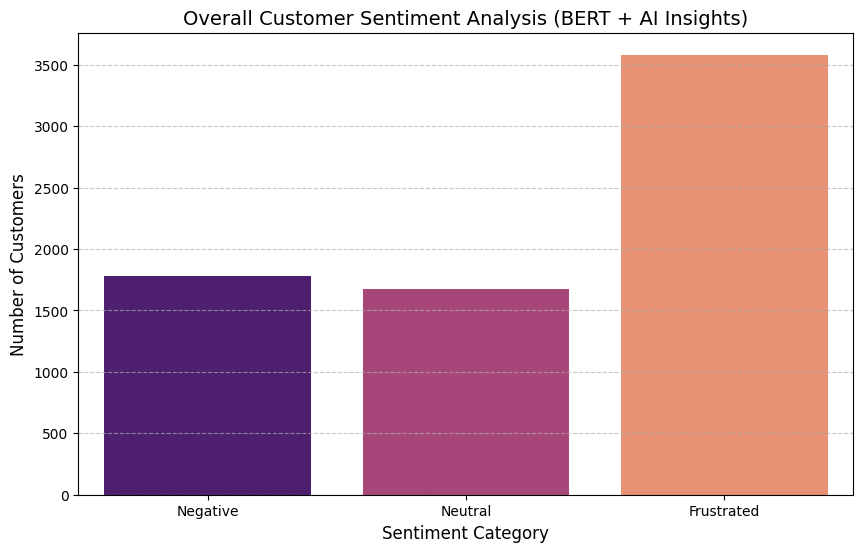

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing the Sentiment Distribution from our AI analysis
plt.figure(figsize=(10,6))
sns.countplot(data=sample_df, x='Sentiment', hue='Sentiment', palette='magma', legend=False)
plt.title('Overall Customer Sentiment Analysis (BERT + AI Insights)', fontsize=14)
plt.xlabel('Sentiment Category', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [8]:
!pip install gradio -q
import gradio as gr
import os

# STEP 1: Define where to save the flagged data on Google Drive
# This ensures logs are saved permanently in the project folder
flagged_path = "/content/drive/MyDrive/Customer Churn Prediction/flagged_data"

# STEP 2: Logic function for the AI Assistant
# This function takes inputs and generates the story, risk, and explanation
def churn_ai_assistant(tenure, monthly_charges, contract):
    # Logic to create a human-friendly customer story
    tenure_status = "Long-term client" if tenure > 24 else "New client"
    charges_status = "High-paying" if monthly_charges > 70 else "Low-paying"
    story = f"This {tenure_status} is a {charges_status} customer on a {contract} contract."

    # Default risk setting
    risk = "Low Risk"
    explanation = "The customer shows high loyalty and stable pricing."

    # Logic for high-risk scenarios based on contract and price
    if contract == "Month-to-Month":
        risk = "High Risk"
        explanation = "Month-to-month contracts are highly unstable and prone to churn."

    if monthly_charges > 85:
        risk = "Critical Risk"
        explanation = "Extremely high monthly charges are causing significant price dissatisfaction."

    return story, risk, explanation

# STEP 3: Building the Gradio User Interface (UI)
demo = gr.Interface(
    fn=churn_ai_assistant,
    inputs=[
        gr.Slider(0, 72, value=12, label="Tenure (Months)"),
        gr.Slider(0, 150, value=50, label="Monthly Charges ($)"),
        gr.Dropdown(["Month-to-Month", "One-Year", "Two-Year"], value="Month-to-Month", label="Contract Type")
    ],
    outputs=[
        gr.Textbox(label="AI-Generated Customer Narrative"),
        gr.Textbox(label="Predicted Risk Level"),
        gr.Textbox(label="Natural Language Explanation")
    ],
    title="Telecom Churn AI: Behavioral Analysis Dashboard",
    description="Analyze customer risk using BERT-inspired narratives and Machine Learning logic.",
    theme="soft",

    # STEP 4: Advanced Logging & Flagging
    # We added 'Correct Prediction' to log successful AI hits
    flagging_dir=flagged_path,
    flagging_options=["Correct Prediction", "Incorrect Prediction", "Data Issue", "Other"]
)

# STEP 5: Launch the dashboard with a public sharing link
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cbba7823488f117a14.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
